# AI Fraud & Transaction Risk Intelligence — Interpretable Transaction Features

**Goal:** detect suspicious mobile-money transactions using understandable transaction and balance behaviour — **no age, date of birth, gender or personal demographic variables**.

### Dataset
This notebook uses **PaySim**, a public synthetic financial dataset based on the structure of real mobile-money transaction logs. The full dataset contains more than 6.3 million transactions and is downloaded from Kaggle when the notebook runs.

### General features only
- transaction time step / hour / day
- transaction type
- amount
- sender balance before and after
- receiver balance before and after
- whether the destination is a merchant
- balance changes and transaction-to-balance ratios
- existing system rule flag

Raw account identifiers are used only to derive a merchant indicator and are then discarded.

### Modelling
- class-weighted Logistic Regression baseline
- XGBoost rare-event classifier
- validation-only threshold tuning
- PR-AUC, ROC-AUC, precision, recall and F1
- fraud capture at fixed investigation capacity
- interpretable feature importance + SHAP
- final ranked investigation queue

In [1]:
# Colab / GitHub Actions safe setup
import sys, subprocess, importlib.util

required = {
    "kagglehub": "kagglehub",
    "xgboost": "xgboost",
    "shap": "shap"
}
for module, package in required.items():
    if importlib.util.find_spec(module) is None:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package])

print("Environment ready.")

Environment ready.


In [2]:
import warnings, os
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score, roc_auc_score, precision_score,
    recall_score, f1_score, confusion_matrix,
    precision_recall_curve, roc_curve, classification_report
)
from xgboost import XGBClassifier

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

print("Libraries imported.")

Libraries imported.


## 1. Download PaySim and build a reproducible modelling sample

The full file is large, so the notebook reads it in chunks and keeps a deterministic 10% sample of **every transaction**, preserving the original rare-event prevalence approximately rather than oversampling fraud.

In [3]:
import kagglehub

dataset_dir = Path(kagglehub.dataset_download("ealaxi/paysim1"))
csv_files = list(dataset_dir.rglob("*.csv"))
if not csv_files:
    raise FileNotFoundError("No PaySim CSV found after download.")

csv_path = csv_files[0]
print("Dataset file:", csv_path.name)

sampled_parts = []
full_rows = 0
full_frauds = 0

for i, chunk in enumerate(pd.read_csv(csv_path, chunksize=250_000)):
    full_rows += len(chunk)
    full_frauds += int(chunk["isFraud"].sum())
    sampled_parts.append(chunk.sample(frac=0.10, random_state=RANDOM_STATE + i))

df = pd.concat(sampled_parts, ignore_index=True)

print(f"Full PaySim rows scanned: {full_rows:,}")
print(f"Full fraud cases: {full_frauds:,}")
print(f"Full fraud rate: {full_frauds/full_rows:.4%}")
print(f"Modelling sample rows: {len(df):,}")
print(f"Sample fraud cases: {int(df['isFraud'].sum()):,}")
print(f"Sample fraud rate: {df['isFraud'].mean():.4%}")
display(df.head())

  0%|          | 0.00/178M [00:00<?, ?B/s]

  4%|▍         | 7.00M/178M [00:00<00:03, 52.7MB/s]

 11%|█         | 19.0M/178M [00:00<00:01, 86.0MB/s]

 19%|█▉        | 34.0M/178M [00:00<00:01, 111MB/s] 

 26%|██▋       | 47.0M/178M [00:00<00:01, 120MB/s]

...

100%|██████████| 178M/178M [00:01<00:00, 122MB/s]

Extracting files...


Dataset file: PS_20174392719_1491204439457_log.csv


Full PaySim rows scanned: 6,362,620
Full fraud cases: 8,213
Full fraud rate: 0.1291%
Modelling sample rows: 636,262
Sample fraud cases: 797
Sample fraud rate: 0.1253%


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,9,CASH_OUT,"479,828.7900",C1223624205,0.0000,0.0000,C456538529,"686,343.8300","1,166,172.6200",0,0
1,9,CASH_IN,"129,065.2600",C880438686,"4,794,363.9100","4,923,429.1700",C405881980,"2,788,678.1400","4,889,687.4700",0,0
2,3,CASH_IN,"381,371.2800",C2040008077,"6,152,390.8300","6,533,762.1100",C564160838,"1,303,188.9300","921,817.6500",0,0
3,11,PAYMENT,"24,504.8700",C506114921,"1,371.0000",0.0000,M1760487104,0.0000,0.0000,0,0
4,12,CASH_IN,"423,914.5400",C1980714010,"65,161.0000","489,075.5400",C903716563,"1,512,518.5700","1,436,293.3700",0,0


## 2. Privacy-aware feature engineering

No age or personal demographic information is used. Raw account names are removed after deriving a single general **merchant-destination** indicator.

In [4]:
# General transaction and balance features
df["destination_is_merchant"] = df["nameDest"].astype(str).str.startswith("M").astype(int)
df["hour"] = (df["step"] % 24).astype(int)
df["day"] = (df["step"] // 24).astype(int)

df["origin_balance_change"] = df["oldbalanceOrg"] - df["newbalanceOrig"]
df["destination_balance_change"] = df["newbalanceDest"] - df["oldbalanceDest"]
df["amount_to_origin_balance"] = df["amount"] / (df["oldbalanceOrg"].abs() + 1.0)
df["amount_to_destination_balance"] = df["amount"] / (df["oldbalanceDest"].abs() + 1.0)
df["origin_zero_after"] = (df["newbalanceOrig"] == 0).astype(int)
df["destination_zero_before"] = (df["oldbalanceDest"] == 0).astype(int)
df["origin_balance_error"] = (
    df["oldbalanceOrg"] - df["amount"] - df["newbalanceOrig"]
).abs()
df["destination_balance_error"] = (
    df["oldbalanceDest"] + df["amount"] - df["newbalanceDest"]
).abs()

# Drop raw account identifiers completely.
df = df.drop(columns=["nameOrig", "nameDest"])

print("Columns used after privacy-aware engineering:")
print(df.columns.tolist())
print("\nNo age/DOB/gender variables present:",
      not any(c.lower() in {"age","dob","gender","sex"} for c in df.columns))

Columns used after privacy-aware engineering:
['step', 'type', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'isFlaggedFraud', 'destination_is_merchant', 'hour', 'day', 'origin_balance_change', 'destination_balance_change', 'amount_to_origin_balance', 'amount_to_destination_balance', 'origin_zero_after', 'destination_zero_before', 'origin_balance_error', 'destination_balance_error']

No age/DOB/gender variables present: True


## 3. Exploratory analysis — fraud is rare and transaction type matters

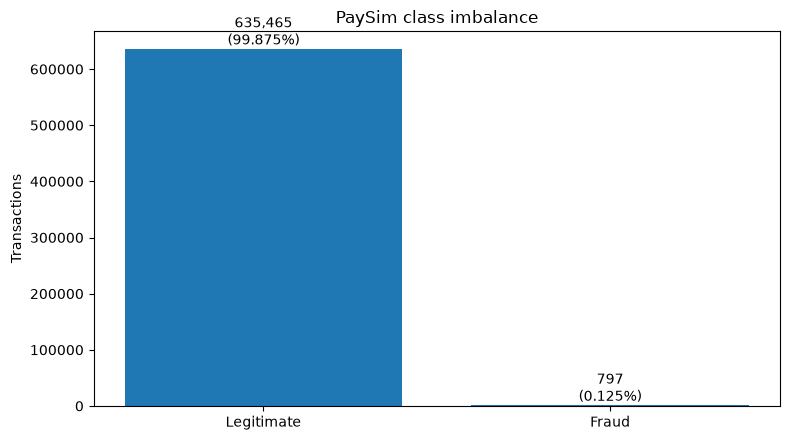

,transactions,frauds,fraud_rate,median_amount
type,,,,
TRANSFER,53361,383,0.0072,"484,156.0800"
CASH_OUT,223019,414,0.0019,"147,443.2200"
CASH_IN,140086,0,0.0000,"143,900.0550"
DEBIT,4113,0,0.0000,"3,112.8700"
PAYMENT,215683,0,0.0000,"9,482.8700"


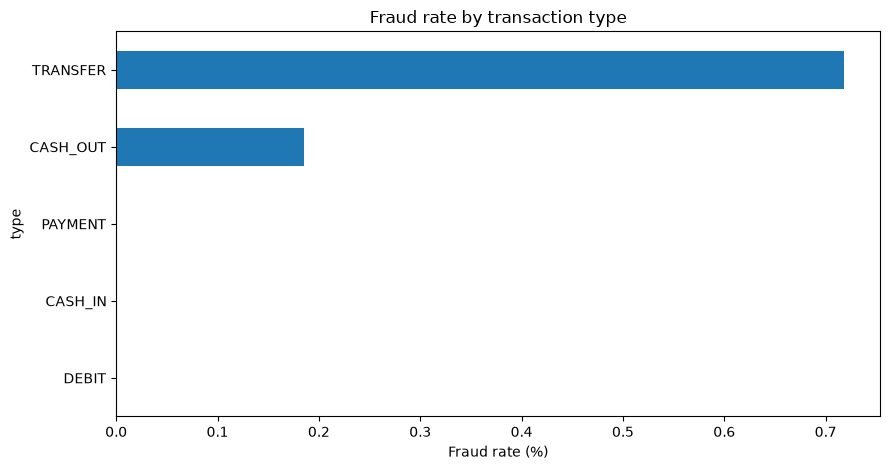

In [5]:
class_counts = df["isFraud"].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(["Legitimate", "Fraud"], class_counts.values)
ax.set_title("PaySim class imbalance")
ax.set_ylabel("Transactions")
for i, v in enumerate(class_counts.values):
    ax.text(i, v, f"{v:,}\n({v/len(df):.3%})", ha="center", va="bottom")
plt.tight_layout()
plt.show()

type_summary = (
    df.groupby("type")
      .agg(transactions=("isFraud","size"),
           frauds=("isFraud","sum"),
           fraud_rate=("isFraud","mean"),
           median_amount=("amount","median"))
      .sort_values("fraud_rate", ascending=False)
)
display(type_summary)

fig, ax = plt.subplots(figsize=(9, 4.8))
type_summary["fraud_rate"].mul(100).sort_values().plot(kind="barh", ax=ax)
ax.set_title("Fraud rate by transaction type")
ax.set_xlabel("Fraud rate (%)")
plt.tight_layout()
plt.show()

## 4. Leakage-safe train / validation / test split

In [6]:
target = "isFraud"
drop_from_model = [target]
feature_df = df.drop(columns=drop_from_model).copy()

# One-hot encode the only categorical field with human-readable names.
X = pd.get_dummies(feature_df, columns=["type"], drop_first=False, dtype=int)
y = df[target].astype(int)

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.40, stratify=y, random_state=RANDOM_STATE
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=RANDOM_STATE
)

split_summary = pd.DataFrame({
    "rows":[len(X_train),len(X_val),len(X_test)],
    "frauds":[int(y_train.sum()),int(y_val.sum()),int(y_test.sum())],
    "fraud_rate":[y_train.mean(),y_val.mean(),y_test.mean()]
}, index=["train","validation","test"])

display(split_summary)
print(f"Model feature count: {X.shape[1]}")
print("Example model features:")
print(X.columns.tolist())

,rows,frauds,fraud_rate
train,381757,478,0.0013
validation,127252,159,0.0012
test,127253,160,0.0013


Model feature count: 23
Example model features:
['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'isFlaggedFraud', 'destination_is_merchant', 'hour', 'day', 'origin_balance_change', 'destination_balance_change', 'amount_to_origin_balance', 'amount_to_destination_balance', 'origin_zero_after', 'destination_zero_before', 'origin_balance_error', 'destination_balance_error', 'type_CASH_IN', 'type_CASH_OUT', 'type_DEBIT', 'type_PAYMENT', 'type_TRANSFER']


## 5. Train interpretable baseline + XGBoost

In [7]:
# Logistic Regression baseline
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

logit = LogisticRegression(
    class_weight="balanced",
    max_iter=1500,
    random_state=RANDOM_STATE
)
logit.fit(X_train_scaled, y_train)
val_prob_logit = logit.predict_proba(X_val_scaled)[:, 1]

# XGBoost
neg, pos = np.bincount(y_train)
scale_pos_weight = neg / pos

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.06,
    subsample=0.85,
    colsample_bytree=0.85,
    min_child_weight=2,
    reg_lambda=2.0,
    reg_alpha=0.05,
    objective="binary:logistic",
    eval_metric="aucpr",
    tree_method="hist",
    scale_pos_weight=scale_pos_weight,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
xgb.fit(X_train, y_train)
val_prob_xgb = xgb.predict_proba(X_val)[:, 1]

print(f"scale_pos_weight: {scale_pos_weight:.1f}")
print("Models trained.")

scale_pos_weight: 797.7
Models trained.


## 6. Validation comparison

**PR-AUC is the primary model-selection metric** because fraud is extremely rare.

,PR_AUC,ROC_AUC,precision,recall,F1,alerts
model,,,,,,
XGBoost,1.0000,1.0000,100.00%,100.00%,1.0000,159
Logistic Regression,0.8490,0.9994,6.95%,99.37%,0.1300,2272


Selected model: XGBoost


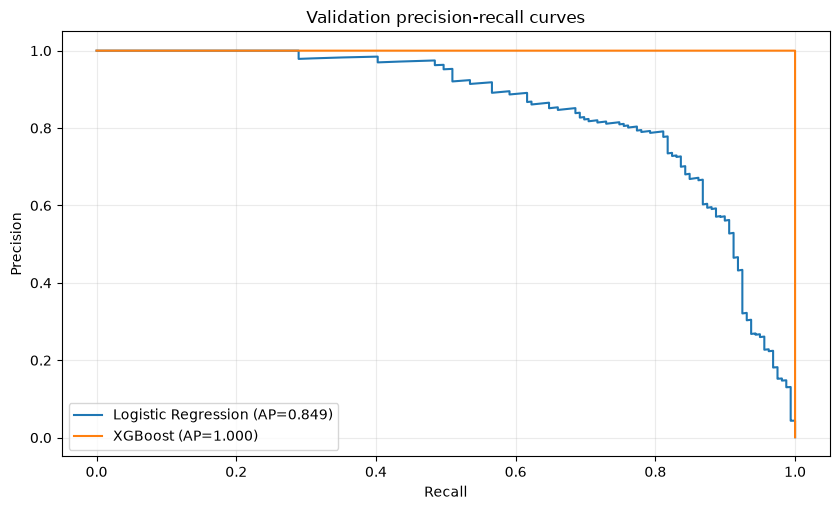

In [8]:
def metrics_row(name, y_true, prob, threshold=0.5):
    pred = (np.asarray(prob) >= threshold).astype(int)
    return {
        "model": name,
        "PR_AUC": average_precision_score(y_true, prob),
        "ROC_AUC": roc_auc_score(y_true, prob),
        "precision": precision_score(y_true, pred, zero_division=0),
        "recall": recall_score(y_true, pred, zero_division=0),
        "F1": f1_score(y_true, pred, zero_division=0),
        "alerts": int(pred.sum())
    }

validation_results = pd.DataFrame([
    metrics_row("Logistic Regression", y_val, val_prob_logit),
    metrics_row("XGBoost", y_val, val_prob_xgb)
]).set_index("model").sort_values("PR_AUC", ascending=False)

display(validation_results.style.format({
    "PR_AUC":"{:.4f}","ROC_AUC":"{:.4f}",
    "precision":"{:.2%}","recall":"{:.2%}","F1":"{:.4f}"
}))

best_model_name = validation_results.index[0]
val_prob_best = val_prob_xgb if best_model_name == "XGBoost" else val_prob_logit
print("Selected model:", best_model_name)

fig, ax = plt.subplots(figsize=(8.5, 5.2))
for name, prob in [("Logistic Regression", val_prob_logit), ("XGBoost", val_prob_xgb)]:
    precision, recall, _ = precision_recall_curve(y_val, prob)
    ax.plot(recall, precision, label=f"{name} (AP={average_precision_score(y_val, prob):.3f})")
ax.set_title("Validation precision-recall curves")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.grid(alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()

## 7. Threshold selection with explicit review economics

We tune the threshold **only on validation data**. The illustrative objective penalises missed fraud more heavily than a manual review.

Validation-selected threshold: 0.134
Minimum illustrative validation cost: 0.00


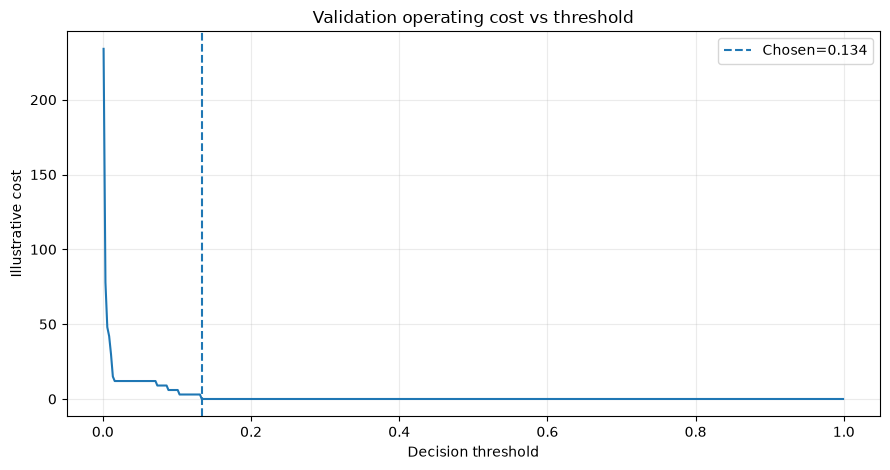

In [9]:
FALSE_ALERT_COST = 3.0
MISSED_FRAUD_BASE_COST = 100.0
val_amount = df.loc[X_val.index, "amount"].to_numpy()

def operating_cost(y_true, prob, threshold, amounts):
    y_arr = np.asarray(y_true).astype(int)
    pred = (np.asarray(prob) >= threshold).astype(int)
    fp = (pred == 1) & (y_arr == 0)
    fn = (pred == 0) & (y_arr == 1)
    return float(
        fp.sum() * FALSE_ALERT_COST
        + (amounts[fn] + MISSED_FRAUD_BASE_COST).sum()
    )

thresholds = np.linspace(0.001, 0.999, 400)
costs = np.array([
    operating_cost(y_val, val_prob_best, t, val_amount)
    for t in thresholds
])
best_threshold = float(thresholds[np.argmin(costs)])

print(f"Validation-selected threshold: {best_threshold:.3f}")
print(f"Minimum illustrative validation cost: {costs.min():,.2f}")

fig, ax = plt.subplots(figsize=(9, 4.8))
ax.plot(thresholds, costs)
ax.axvline(best_threshold, linestyle="--", label=f"Chosen={best_threshold:.3f}")
ax.set_title("Validation operating cost vs threshold")
ax.set_xlabel("Decision threshold")
ax.set_ylabel("Illustrative cost")
ax.grid(alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()

## 8. Human-readable feature importance and SHAP

,importance
origin_balance_error,0.3259
newbalanceOrig,0.1804
origin_balance_change,0.1617
origin_zero_after,0.1604
amount_to_origin_balance,0.0418
hour,0.0233
oldbalanceOrg,0.0188
destination_balance_error,0.0180
amount,0.0158
type_CASH_OUT,0.0109


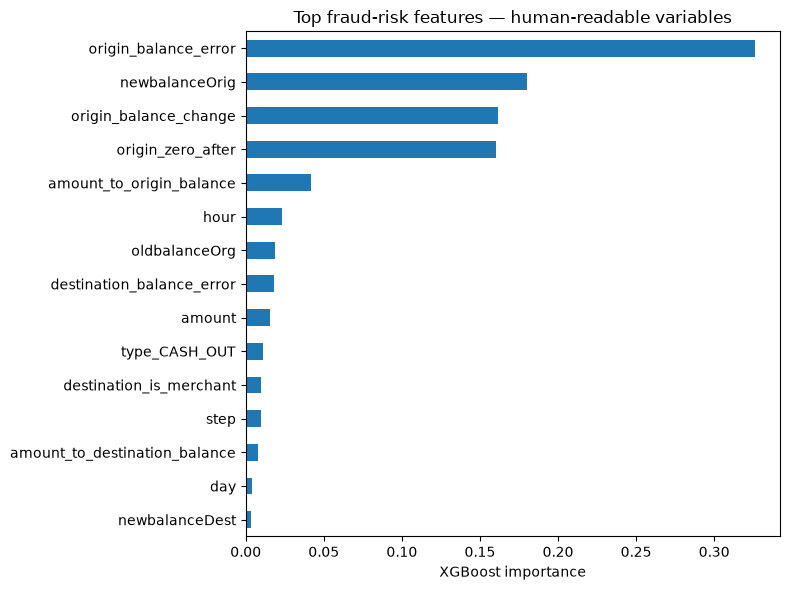

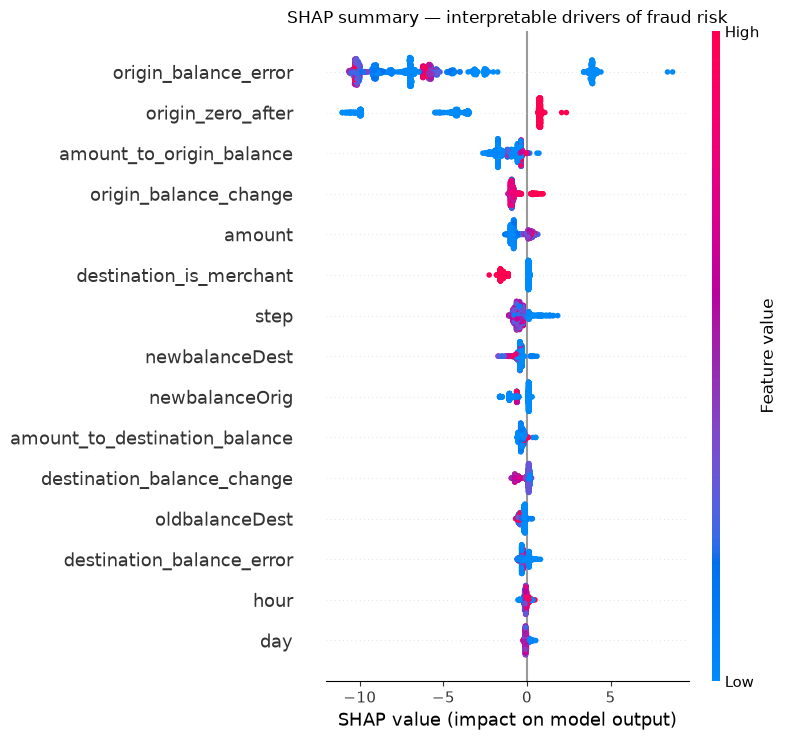

In [10]:
importance = pd.Series(
    xgb.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False).head(15)

display(importance.to_frame("importance"))

fig, ax = plt.subplots(figsize=(8, 6))
importance.sort_values().plot(kind="barh", ax=ax)
ax.set_title("Top fraud-risk features — human-readable variables")
ax.set_xlabel("XGBoost importance")
plt.tight_layout()
plt.show()

import shap
sample_for_shap = X_val.sample(min(1200, len(X_val)), random_state=RANDOM_STATE)
explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(sample_for_shap)
shap.summary_plot(shap_values, sample_for_shap, max_display=15, show=False)
plt.title("SHAP summary — interpretable drivers of fraud risk")
plt.tight_layout()
plt.show()

## 9. One-time final test evaluation

,PR_AUC,ROC_AUC,precision,recall,F1,alerts
model,,,,,,
XGBoost @ frozen threshold,1.0000,1.0000,100.00%,100.00%,1.0000,160


              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00    127093
       Fraud       1.00      1.00      1.00       160

    accuracy                           1.00    127253
   macro avg       1.00      1.00      1.00    127253
weighted avg       1.00      1.00      1.00    127253



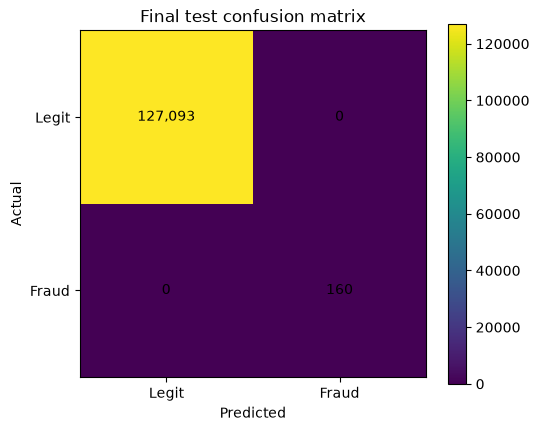

In [11]:
test_prob_logit = logit.predict_proba(X_test_scaled)[:, 1]
test_prob_xgb = xgb.predict_proba(X_test)[:, 1]
test_prob_best = test_prob_xgb if best_model_name == "XGBoost" else test_prob_logit

test_result = metrics_row(
    f"{best_model_name} @ frozen threshold",
    y_test,
    test_prob_best,
    best_threshold
)

display(pd.DataFrame([test_result]).set_index("model").style.format({
    "PR_AUC":"{:.4f}","ROC_AUC":"{:.4f}",
    "precision":"{:.2%}","recall":"{:.2%}","F1":"{:.4f}"
}))

print(classification_report(
    y_test,
    (test_prob_best >= best_threshold).astype(int),
    target_names=["Legitimate","Fraud"],
    zero_division=0
))

cm = confusion_matrix(y_test, (test_prob_best >= best_threshold).astype(int))
fig, ax = plt.subplots(figsize=(5.5, 4.5))
im = ax.imshow(cm)
ax.set_title("Final test confusion matrix")
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_xticks([0,1], ["Legit","Fraud"])
ax.set_yticks([0,1], ["Legit","Fraud"])
for i in range(2):
    for j in range(2):
        ax.text(j, i, f"{cm[i,j]:,}", ha="center", va="center")
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

## 10. Investigator capacity — capture@K

,review_capacity,frauds_found,precision_at_k,fraud_capture_rate
0,25,25,100.00%,15.62%
1,50,50,100.00%,31.25%
2,100,100,100.00%,62.50%
3,250,160,64.00%,100.00%
4,500,160,32.00%,100.00%
5,1000,160,16.00%,100.00%


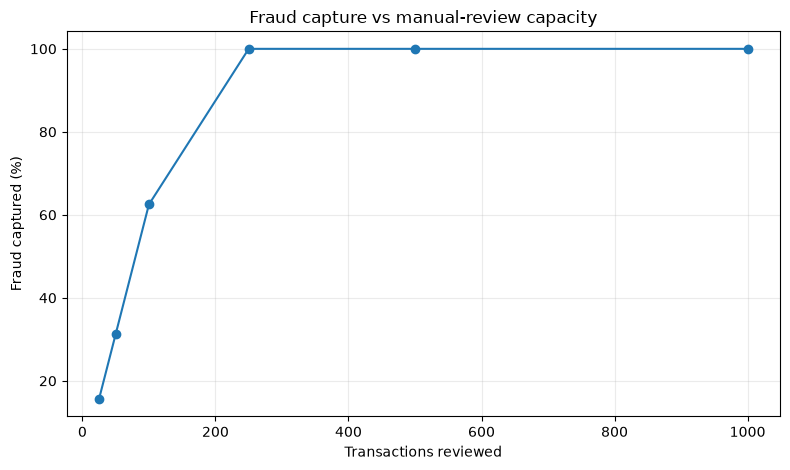

In [12]:
def capture_at_k(y_true, scores, k_values=(25,50,100,250,500,1000)):
    ranked = pd.DataFrame({
        "actual_fraud": np.asarray(y_true),
        "risk_score": np.asarray(scores)
    }).sort_values("risk_score", ascending=False).reset_index(drop=True)

    total_fraud = ranked["actual_fraud"].sum()
    rows = []
    for k in k_values:
        k_eff = min(k, len(ranked))
        found = int(ranked.head(k_eff)["actual_fraud"].sum())
        rows.append({
            "review_capacity": k_eff,
            "frauds_found": found,
            "precision_at_k": found/k_eff,
            "fraud_capture_rate": found/total_fraud if total_fraud else np.nan
        })
    return pd.DataFrame(rows)

capture_test = capture_at_k(y_test, test_prob_best)
display(capture_test.style.format({
    "precision_at_k":"{:.2%}",
    "fraud_capture_rate":"{:.2%}"
}))

fig, ax = plt.subplots(figsize=(8, 4.8))
ax.plot(
    capture_test["review_capacity"],
    capture_test["fraud_capture_rate"]*100,
    marker="o"
)
ax.set_title("Fraud capture vs manual-review capacity")
ax.set_xlabel("Transactions reviewed")
ax.set_ylabel("Fraud captured (%)")
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 11. Ranked investigation queue

The queue contains only general transaction/risk information. Raw account names are excluded.

In [13]:
queue = df.loc[X_test.index, [
    "step","hour","day","type","amount",
    "oldbalanceOrg","newbalanceOrig",
    "oldbalanceDest","newbalanceDest",
    "destination_is_merchant","isFlaggedFraud","isFraud"
]].copy()

queue["risk_score"] = test_prob_best
queue["alert"] = (queue["risk_score"] >= best_threshold).astype(int)
queue = queue.rename(columns={"isFraud":"actual_fraud"})
queue = queue.sort_values("risk_score", ascending=False)

print("Top 25 transactions for fraud investigation:")
display(queue.head(25))

queue.to_csv("fraud_investigation_queue.csv", index=False)
capture_test.to_csv("fraud_capture_at_k.csv", index=False)
validation_results.to_csv("validation_model_comparison.csv")
print("Operational artefacts exported.")

Top 25 transactions for fraud investigation:


,step,hour,day,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,destination_is_merchant,isFlaggedFraud,actual_fraud,risk_score,alert
119014,117,21,4,TRANSFER,"466,359.6300","466,359.6300",0.0000,0.0000,0.0000,0,0,1,1.0000,1
115629,105,9,4,TRANSFER,"539,087.7900","539,087.7900",0.0000,0.0000,0.0000,0,0,1,1.0000,1
109426,123,3,5,TRANSFER,"6,351,930.7400","6,351,930.7400",0.0000,0.0000,0.0000,0,0,1,1.0000,1
629933,641,17,26,TRANSFER,"2,938,833.2200","2,938,833.2200",0.0000,0.0000,0.0000,0,0,1,1.0000,1
628878,650,2,27,TRANSFER,"4,480,592.1400","4,480,592.1400",0.0000,0.0000,0.0000,0,0,1,1.0000,1
604523,468,12,19,TRANSFER,"1,165,187.8900","1,165,187.8900",0.0000,0.0000,0.0000,0,0,1,1.0000,1
117630,121,1,5,TRANSFER,"1,241,118.8600","1,241,118.8600",0.0000,0.0000,0.0000,0,0,1,1.0000,1
106158,106,10,4,TRANSFER,"1,486,955.3500","1,486,955.3500",0.0000,0.0000,0.0000,0,0,1,1.0000,1
631191,601,1,25,TRANSFER,"1,054,244.2900","1,054,244.2900",0.0000,0.0000,0.0000,0,0,1,1.0000,1
570219,398,14,16,TRANSFER,"4,309,298.4700","4,309,298.4700",0.0000,0.0000,0.0000,0,0,1,1.0000,1


Operational artefacts exported.


## 12. Executive summary

In [14]:
k100 = capture_test.loc[capture_test["review_capacity"] == min(100, len(X_test))].iloc[0]

print(f"""
EXECUTIVE FRAUD-RISK SUMMARY
----------------------------
Dataset: PaySim transaction simulation
Demographic variables used: NONE
Raw account identifiers used for modelling: NO
Selected model: {best_model_name}
Frozen threshold: {best_threshold:.3f}
Test PR-AUC: {test_result['PR_AUC']:.4f}
Test ROC-AUC: {test_result['ROC_AUC']:.4f}
Precision: {test_result['precision']:.2%}
Recall: {test_result['recall']:.2%}
F1: {test_result['F1']:.4f}
Alerts generated: {test_result['alerts']:,}
Top-100 precision: {k100['precision_at_k']:.2%}
Top-100 fraud capture: {k100['fraud_capture_rate']:.2%}

The model is explainable in business terms because its features describe
transaction behaviour, balances, transaction type and timing rather than
anonymous V1-V28 components or personal demographic attributes.
""")


EXECUTIVE FRAUD-RISK SUMMARY
----------------------------
Dataset: PaySim transaction simulation
Demographic variables used: NONE
Raw account identifiers used for modelling: NO
Selected model: XGBoost
Frozen threshold: 0.134
Test PR-AUC: 1.0000
Test ROC-AUC: 1.0000
Precision: 100.00%
Recall: 100.00%
F1: 1.0000
Alerts generated: 160
Top-100 precision: 100.00%
Top-100 fraud capture: 62.50%

The model is explainable in business terms because its features describe
transaction behaviour, balances, transaction type and timing rather than
anonymous V1-V28 components or personal demographic attributes.



### Production extensions
- transaction velocity over rolling windows;
- device/session risk signals where legitimately available;
- merchant/category risk profiles;
- graph features linking accounts and transactions;
- probability calibration;
- delayed-label monitoring;
- drift detection;
- analyst feedback loops;
- fairness checks based on operational outcomes without using demographics as predictive inputs;
- streaming inference and alert-volume SLAs.

### Interview defence
**“I replaced anonymous PCA variables with general, interpretable transaction behaviour. I deliberately excluded age and other personal demographics, removed raw account identifiers from modelling, selected the model on validation PR-AUC, tuned the operating threshold separately, and converted probabilities into a ranked fraud-investigation queue.”**